In [2]:
# Cell 1

#import libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set randon seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# Cell 2


# Training transform includes augmentation (slight improvement over the lab version)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

# Test transform stays clean - no augmentation, we want real test conditions
transform_test = transforms.Compose([
    transforms.ToTensor(),
])

# Download training images (50,000 images)
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

# Download test images (10,000 images)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

# These are the 10 categories in CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print("Download complete!")
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 170M/170M [00:07<00:00, 22.8MB/s]


Download complete!
Training images: 50000
Test images: 10000


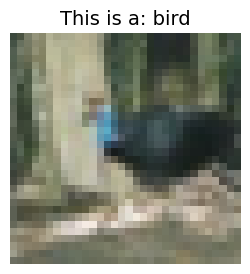

Label number: 2
Label name: bird


In [4]:
# Cell 3

# Pick one image from the test dataset to look at
# Can change this number to see different images
image_number = 8765

# Get the image and its label
image, label = test_dataset[image_number]

# Display the image
plt.figure(figsize=(3,3))
plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
plt.title('This is a: ' + classes[label], fontsize=14)
plt.axis('off')
plt.show()

print("Label number:", label)
print("Label name:", classes[label])

In [5]:
# Cell 4

# Build the neural network
class CIFAR10_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Layer 1: looks at small patches of the image
            nn.Conv2d(3, 6, 5),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Layer 2: looks at bigger patterns
            nn.Conv2d(6, 16, 5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Flatten: converts the image into a single long list of numbers
            nn.Flatten(),

            # Layer 3: starts making decisions
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),

            # Layer 4: narrows down the decision
            nn.Linear(120, 84),
            nn.ReLU(),

            # Layer 5: final output, one score for each of the 10 categories
            nn.Linear(84, 10),
        )

    def forward(self, x):
        x = x.view(-1, 3, 32, 32)
        x = self.model(x)
        return x

# Create the model
model = CIFAR10_Model()
print("Neural network built successfully!")
print(model)

Neural network built successfully!
CIFAR10_Model(
  (model): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=400, out_features=120, bias=True)
    (10): ReLU()
    (11): Linear(in_features=120, out_features=84, bias=True)
    (12): ReLU()
    (13): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [6]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               # Cell 5
# Cell 5

# Training settings
BATCH_SIZE = 128
lr = 0.001
nepoch = 30

# Load training data in batches
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Load test data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Loss function and optimiser
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Using device:", device)

# Training mode
print("Starting training...")
for epoch in range(nepoch):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        # Backpropagation
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Evaluation on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{nepoch} | Loss: {total_loss/len(train_loader):.4f} | Accuracy: {accuracy:.1f}%")
print("Training complete! ")



Using device: cuda
Starting training...
Epoch 1/30 | Loss: 1.6526 | Accuracy: 37.5%
Epoch 2/30 | Loss: 1.4146 | Accuracy: 51.4%
Epoch 3/30 | Loss: 1.3244 | Accuracy: 57.5%
Epoch 4/30 | Loss: 1.2713 | Accuracy: 50.6%
Epoch 5/30 | Loss: 1.2265 | Accuracy: 56.8%
Epoch 6/30 | Loss: 1.1896 | Accuracy: 61.1%
Epoch 7/30 | Loss: 1.1664 | Accuracy: 61.9%
Epoch 8/30 | Loss: 1.1486 | Accuracy: 56.5%
Epoch 9/30 | Loss: 1.1225 | Accuracy: 58.0%
Epoch 10/30 | Loss: 1.1121 | Accuracy: 61.9%
Epoch 11/30 | Loss: 1.0924 | Accuracy: 54.1%
Epoch 12/30 | Loss: 1.0711 | Accuracy: 64.7%
Epoch 13/30 | Loss: 1.0634 | Accuracy: 60.0%
Epoch 14/30 | Loss: 1.0493 | Accuracy: 65.0%
Epoch 15/30 | Loss: 1.0430 | Accuracy: 51.4%
Epoch 16/30 | Loss: 1.0304 | Accuracy: 63.8%
Epoch 17/30 | Loss: 1.0201 | Accuracy: 61.0%
Epoch 18/30 | Loss: 1.0118 | Accuracy: 65.5%
Epoch 19/30 | Loss: 1.0035 | Accuracy: 62.1%
Epoch 20/30 | Loss: 0.9983 | Accuracy: 65.4%
Epoch 21/30 | Loss: 0.9921 | Accuracy: 65.2%
Epoch 22/30 | Loss: 0.98

In [7]:
# Cell 6

# Evaluate model performance on unseen test images
correct = 0
total = 0

# Switch to evaluation mode
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on 10,000 test images: {accuracy:.2f}%")
print(f"Correct: {correct} out of {total}")

Accuracy on 10,000 test images: 68.32%
Correct: 6832 out of 10000


In [8]:
# Cell 7

# Function to test a single image and show what the network thinks
def show_image_and_prediction(image_number):
    # Get the image and correct label
    image, true_label = test_dataset[image_number]

    # Run it through the network
    model.eval()
    with torch.no_grad():
        image_input = image.unsqueeze(0).to(device)
        output = model(image_input)
        predicted_label = torch.argmax(output).item()

    # Display the image
    plt.figure(figsize=(3, 3))
    plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
    plt.title(f"True: {classes[true_label]}\nNetwork says: {classes[predicted_label]}", fontsize=12)
    plt.axis('off')
    plt.show()

    # Print whether prediction was correct
    if predicted_label == true_label:
        print(f"Image {image_number}: CORRECT - Network correctly identified as {classes[true_label]}")
    else:
        print(f"Image {image_number}: WRONG - True label is {classes[true_label]} but network said {classes[predicted_label]}")

    return predicted_label == true_label


# Find one correctly classified image per class
# This ensures our adversarial examples cover all 10 categories
print("Searching for one correct image per class...")

good_images = {}  # key = class index, value = image index
i = 0

while len(good_images) < 10 and i < len(test_dataset):
    image, true_label = test_dataset[i]

    model.eval()
    with torch.no_grad():
        image_input = image.unsqueeze(0).to(device)
        output = model(image_input)
        predicted_label = torch.argmax(output).item()

    # Store one correct image per class
    if predicted_label == true_label and true_label not in good_images:
        good_images[true_label] = i

    i += 1

print("Selected images:")
for cls, idx in good_images.items():
    print(f"{classes[cls]} → image #{idx}")

Searching for one correct image per class...
Selected images:
cat → image #0
plane → image #3
frog → image #4
car → image #9
truck → image #11
horse → image #13
ship → image #15
dog → image #16
deer → image #26
bird → image #65


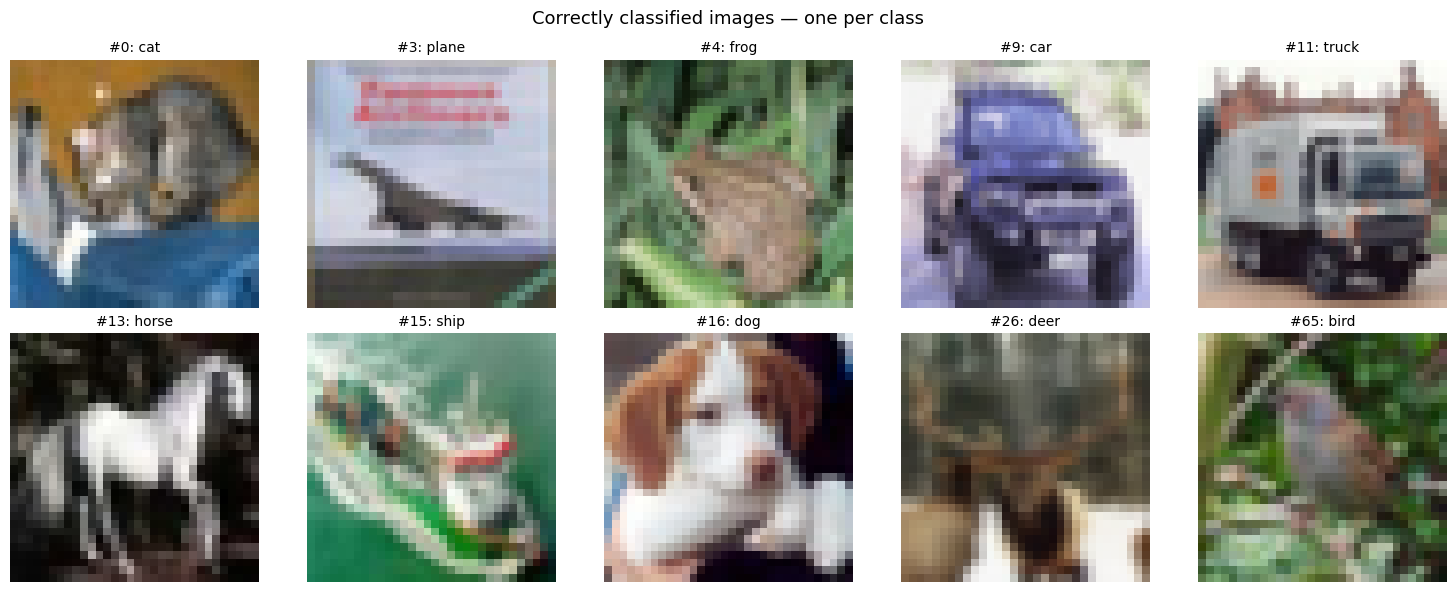

In [9]:
# Cell 8

# Display one correctly classified image from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, (cls, img_num) in enumerate(good_images.items()):
    #Get image and label
    image, true_label = test_dataset[img_num]
    # Convert image into display format
    img_display = np.clip(np.transpose(image.numpy(), (1, 2, 0)), 0, 1)
    axes[idx].imshow(img_display)
    axes[idx].set_title(f"#{img_num}: {classes[true_label]}", fontsize=10)
    axes[idx].axis('off')
plt.suptitle("Correctly classified images — one per class", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Cell 9

def fgsm_attack(image, label, epsilon):
    """
    FGSM: Fast Gradient Sign Method
    Takes one image, computes the gradient of the loss
    with respect to the input, then nudges the image
    in the direction that maximises the loss.
    """
    # Convert label to tensor
    label_tensor = torch.tensor([label]).to(device)

    # Make a copy of the image that tracks gradients
    # (normally images don't need gradients, only weights do)
    image_input = image.unsqueeze(0).to(device)
    image_input.requires_grad = True

    # Forward pass
    model.eval()
    output = model(image_input)

    # Calculate loss
    loss = criterion(output, label_tensor)

    # Backward pass — but we want gradient w.r.t. INPUT, not weights
    model.zero_grad()
    loss.backward()

    # Get the sign of the gradient
    gradient_sign = image_input.grad.data.sign()

    # Create adversarial image by nudging in gradient direction
    adversarial_image = image_input + epsilon * gradient_sign

    # Keep pixel values within the valid image range
    adversarial_image = torch.clamp(adversarial_image, 0, 1)

    return adversarial_image.squeeze(0).detach().cpu()

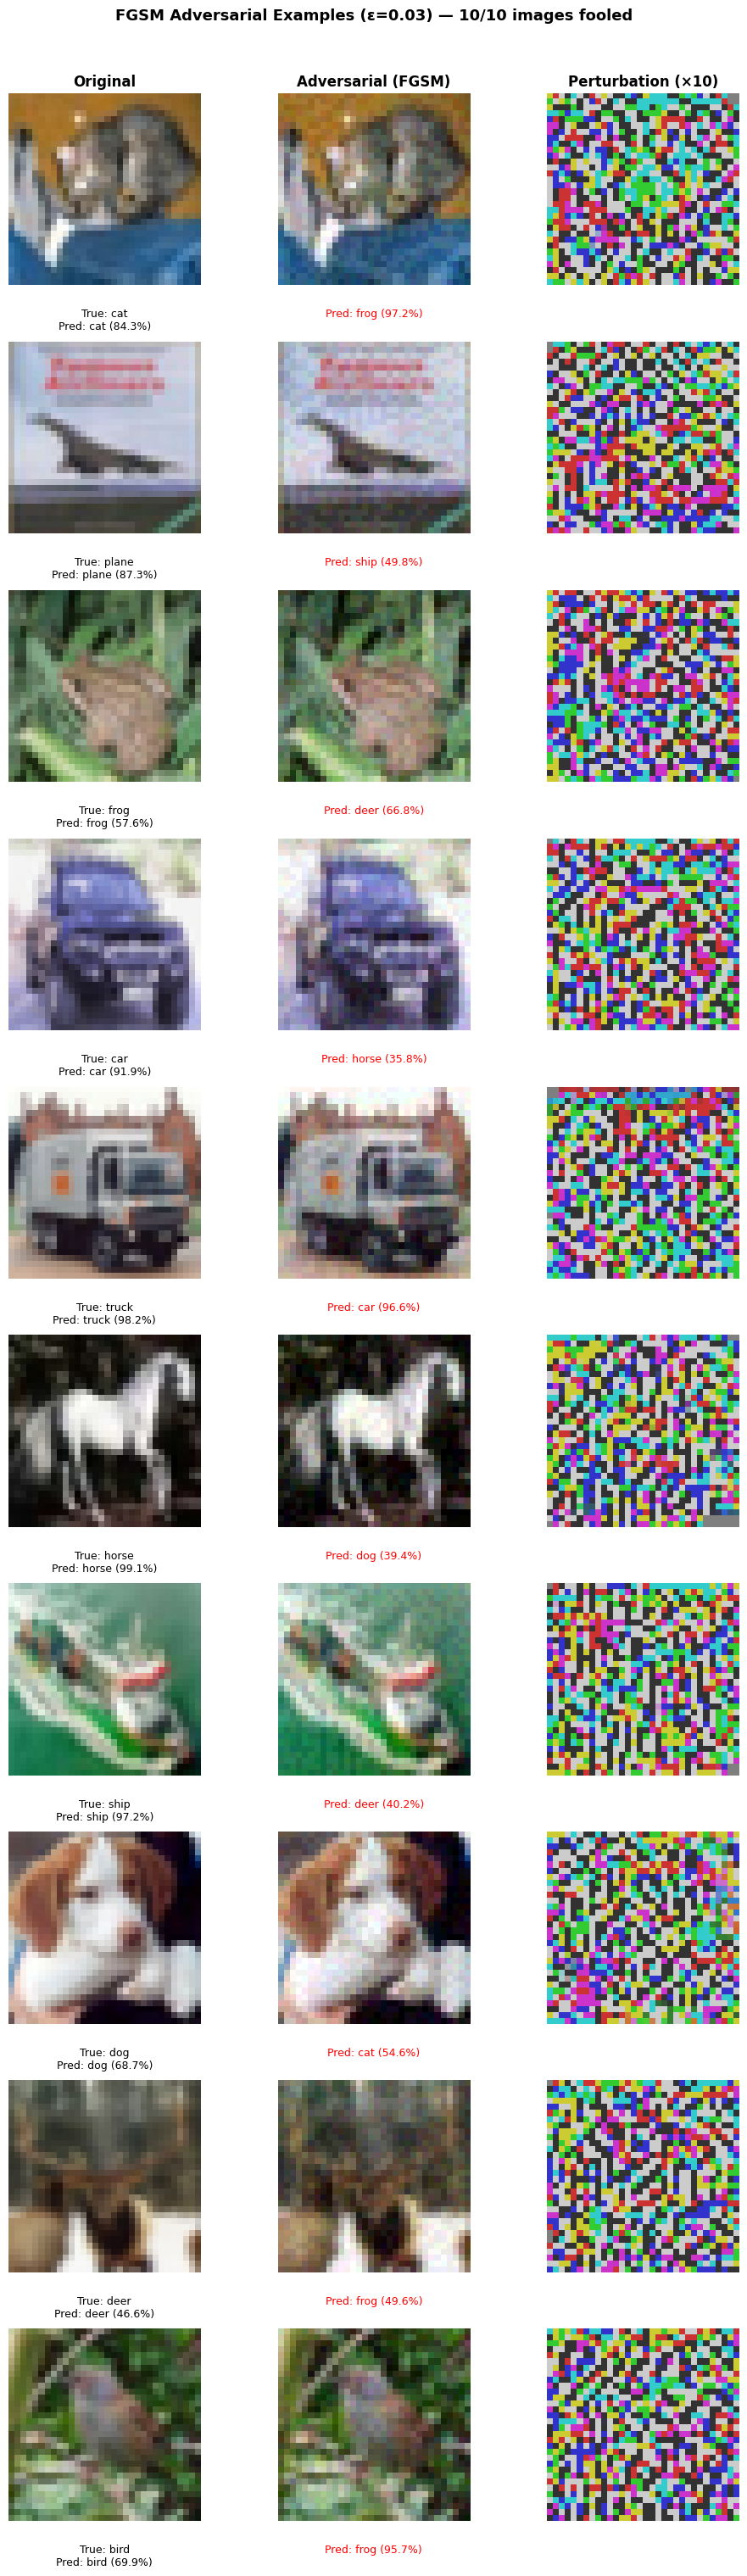


FGSM fooled the network on 10/10 images (ε=0.03)


In [11]:
# Cell 10

epsilon = 0.03  # Small perturbation strength

fig, axes = plt.subplots(10, 3, figsize=(10, 30))

# Titles for each column
col_titles = ['Original', 'Adversarial (FGSM)', 'Perturbation (×10)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

n_fooled = 0  # Count successful attacks

for row, (cls_idx, img_num) in enumerate(good_images.items()):

    # Get image and true label
    image, true_label = test_dataset[img_num]

    # Generate adversarial example using FGSM
    adv_image = fgsm_attack(image, true_label, epsilon)

    # Get predictions before and after attack
    model.eval()
    with torch.no_grad():

        # Original prediction
        orig_output = model(image.unsqueeze(0).to(device))
        orig_probs = torch.softmax(orig_output, dim=1)
        orig_pred = torch.argmax(orig_output).item()
        orig_conf = orig_probs[0][orig_pred].item() * 100

        # Adversarial prediction
        adv_output = model(adv_image.unsqueeze(0).to(device))
        adv_probs = torch.softmax(adv_output, dim=1)
        adv_pred = torch.argmax(adv_output).item()
        adv_conf = adv_probs[0][adv_pred].item() * 100

    # Count how many images were successfully fooled
    if adv_pred != true_label:
        n_fooled += 1

    #-------------------------------
    # Column 1: Original image

    axes[row, 0].imshow(
        np.clip(np.transpose(image.numpy(), (1, 2, 0)), 0, 1)
    )

    # Show true label + prediction
    axes[row, 0].text(
        0.5, -0.12,
        f"True: {classes[true_label]}\nPred: {classes[orig_pred]} ({orig_conf:.1f}%)",
        ha='center',
        va='top',
        transform=axes[row, 0].transAxes,
        fontsize=9
    )

    axes[row, 0].axis('off')

    # -------------------------------
    # Column 2: Adversarial image

    axes[row, 1].imshow(
        np.clip(np.transpose(adv_image.numpy(), (1, 2, 0)), 0, 1)
    )

    # Red text if attack was successful
    color = 'red' if adv_pred != true_label else 'green'

    axes[row, 1].text(
        0.5, -0.12,
        f"Pred: {classes[adv_pred]} ({adv_conf:.1f}%)",
        ha='center',
        va='top',
        transform=axes[row, 1].transAxes,
        fontsize=9,
        color=color
    )

    axes[row, 1].axis('off')

    # -------------------------------
    # Column 3: Perturbation

    # Calculate Perturbation
    perturbation = (adv_image - image) * 10 + 0.5

    # Amplify perturbation so it becomes visible
    perturbation = torch.clamp(perturbation, 0, 1)

    axes[row, 2].imshow(
        np.transpose(perturbation.numpy(), (1, 2, 0))
    )

    axes[row, 2].axis('off')

# Overall title
plt.suptitle(
    f"FGSM Adversarial Examples (ε={epsilon}) — {n_fooled}/10 images fooled",
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

print(f"\nFGSM fooled the network on {n_fooled}/10 images (ε={epsilon})")

ε=0.00 → Accuracy: 67.8%
ε=0.01 → Accuracy: 15.8%
ε=0.02 → Accuracy: 5.0%
ε=0.03 → Accuracy: 2.8%
ε=0.05 → Accuracy: 1.6%
ε=0.10 → Accuracy: 3.6%
ε=0.15 → Accuracy: 4.8%
ε=0.20 → Accuracy: 6.0%


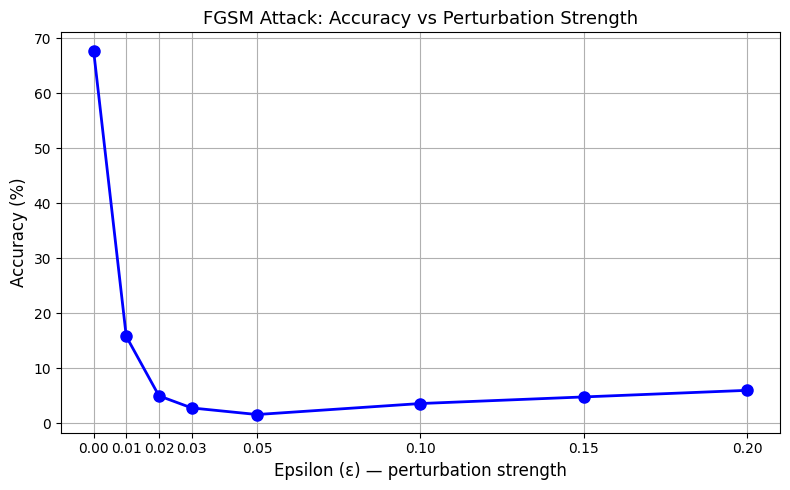

In [12]:
# Cell 11 — How does attack strength affect accuracy?

# Different perturbation strengths to test
epsilons = [0, 0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2]
accuracies = []

for eps in epsilons:
    correct = 0
    total = 0

    # Test on first 500 images for speed
    for img_num in range(500):
        image, true_label = test_dataset[img_num]

        # No attack when epsilon = 0
        if eps == 0:
            adv_image = image

        # Generate FGSM adversarial image
        else:
            adv_image = fgsm_attack(image, true_label, eps)
        model.eval()
        with torch.no_grad():
            output = model(adv_image.unsqueeze(0).to(device))
            pred = torch.argmax(output).item()

        # Count correct predictions
        if pred == true_label:
            correct += 1
        total += 1
    acc = 100 * correct / total
    accuracies.append(acc)
    print(f"ε={eps:.2f} → Accuracy: {acc:.1f}%")

# Plot accuracy against epsilon
plt.figure(figsize=(8, 5))
plt.plot(epsilons, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Epsilon (ε) — perturbation strength', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('FGSM Attack: Accuracy vs Perturbation Strength', fontsize=13)
plt.grid(True)
plt.xticks(epsilons)
plt.tight_layout()
plt.show()

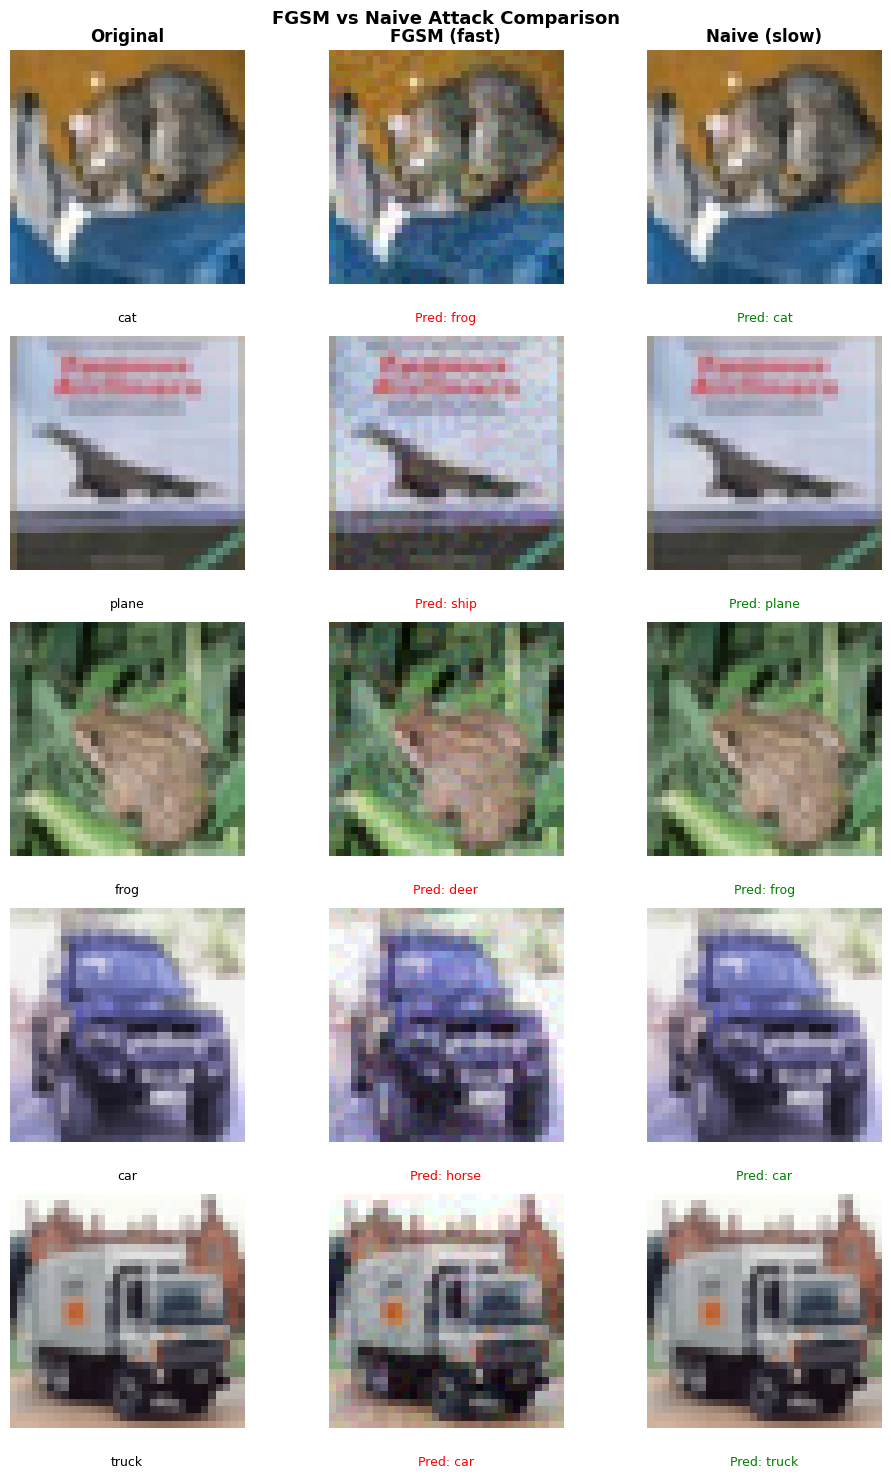

FGSM fooled 5/5 images
Naive attack fooled 0/5 images


In [13]:
# Cell 12 — Naive random attack (from lecture notes Section 6.6.1)
# Compare FGSM with a simple random perturbation attack

def naive_attack(image, true_label, n_iter=2000, epsilon=0.03):
    """
    Naive adversarial attack from lecture notes Section 6.6.1.
    Randomly perturbs pixels and checks whether
    the prediction changes.
    """

    x = image.clone()

    model.eval()
    with torch.no_grad():
        output = model(x.unsqueeze(0).to(device))
        pred = torch.argmax(output).item()

    # If already wrong, return immediately
    if pred != true_label:
        return x, pred

    for _ in range(n_iter):

        x_new = x.clone()

        # Randomly select one pixel channel
        c = np.random.randint(0, 3)
        i = np.random.randint(0, 32)
        j = np.random.randint(0, 32)

        # Add small random noise
        x_new[c, i, j] += np.random.randn() * epsilon

        # Keep values in valid image range
        x_new = torch.clamp(x_new, 0, 1)

        with torch.no_grad():
            output = model(x_new.unsqueeze(0).to(device))
            new_pred = torch.argmax(output).item()

        # Stop once prediction changes
        if new_pred != true_label:
            return x_new, new_pred

    # Return original image if attack fails
    return x, pred


# Use first 5 selected images
selected = list(good_images.items())[:5]

fig, axes = plt.subplots(5, 3, figsize=(10, 15))

# Column titles
col_titles = ['Original', 'FGSM (fast)', 'Naive (slow)']

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

# Count successful attacks
n_fgsm_fooled = 0
n_naive_fooled = 0

for row, (cls_idx, img_num) in enumerate(selected):

    # Get image and label
    image, true_label = test_dataset[img_num]

    # Generate FGSM adversarial example
    fgsm_adv = fgsm_attack(image, true_label, epsilon=0.03)

    # Generate naive adversarial example
    naive_adv, naive_pred = naive_attack(image, true_label)

    model.eval()

    with torch.no_grad():

        # Original prediction
        orig_pred = torch.argmax(
            model(image.unsqueeze(0).to(device))
        ).item()

        # FGSM prediction
        fgsm_pred = torch.argmax(
            model(fgsm_adv.unsqueeze(0).to(device))
        ).item()

    # Count successful attacks
    if fgsm_pred != true_label:
        n_fgsm_fooled += 1

    if naive_pred != true_label:
        n_naive_fooled += 1


    # -----------------------------------
    # Column 1: original image

    axes[row, 0].imshow(
        np.clip(np.transpose(image.numpy(), (1, 2, 0)), 0, 1)
    )

    # Show true class
    axes[row, 0].text(
        0.5, -0.12,
        f"{classes[true_label]}",
        ha='center',
        va='top',
        transform=axes[row, 0].transAxes,
        fontsize=9
    )

    axes[row, 0].axis('off')


    # -----------------------------------
    # Column 2: FGSM attack

    axes[row, 1].imshow(
        np.clip(np.transpose(fgsm_adv.numpy(), (1, 2, 0)), 0, 1)
    )

    # # Red text if attack was successful
    color = 'red' if fgsm_pred != true_label else 'green'

    axes[row, 1].text(
        0.5, -0.12,
        f"Pred: {classes[fgsm_pred]}",
        ha='center',
        va='top',
        transform=axes[row, 1].transAxes,
        fontsize=9,
        color=color
    )

    axes[row, 1].axis('off')


    # -----------------------------------
    # Column 3: naive attack

    axes[row, 2].imshow(
        np.clip(np.transpose(naive_adv.numpy(), (1, 2, 0)), 0, 1)
    )

    # Red if attack successful
    color = 'red' if naive_pred != true_label else 'green'

    axes[row, 2].text(
        0.5, -0.12,
        f"Pred: {classes[naive_pred]}",
        ha='center',
        va='top',
        transform=axes[row, 2].transAxes,
        fontsize=9,
        color=color
    )

    axes[row, 2].axis('off')


plt.suptitle(
    "FGSM vs Naive Attack Comparison",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Print summary
print(f"FGSM fooled {n_fgsm_fooled}/5 images")
print(f"Naive attack fooled {n_naive_fooled}/5 images")